# Figure Reproduction for Policy Brief USA (English Version)

This notebook reproduces the visualizations for the Policy Brief using processed data from the `images/` directory.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# Global style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.sans-serif'] = ['Arial']

print("Libraries loaded successfully.")

## Figure 2: U.S. Trade Dependency by Sector (English)

This visualization shows the high-level dependency of the U.S. on different countries, broken down by major sectors.

In [ ]:
def plot_dependencies_by_sector_en(csv_path, output_image_name):
    df = pd.read_csv(csv_path)
    sectores_raw = ['manufacturas', 'agricultura', 'servicios', 'minería y energía']
    sector_translation = {'manufacturas': 'Manufacturing', 'agricultura': 'Agriculture', 'servicios': 'Services', 'minería y energía': 'Mining & Energy'}
    country_translation = {"China": "China", "México": "Mexico", "Vietnam": "Vietnam", "Canadá": "Canada", "Japón": "Japan", "RUS": "Russia", "Taiwán": "Taiwan", "Alemania": "Germany", "Irlanda": "Ireland", "Corea del Sur": "South Korea", "India": "India", "Tailandia": "Thailand", "Malasia": "Malaysia", "Suiza": "Switzerland", "Francia": "France", "Brasil": "Brazil", "Italia": "Italy", "Reino Unido": "United Kingdom", "Países Bajos": "Netherlands", "Bermudas": "Bermuda", "Singapur": "Singapore"}
    
    countries = df['country'].tolist()
    country_labels = [country_translation.get(name, name) for name in df['country_name']]
    fig, ax = plt.subplots(figsize=(16, 8))
    num_sectors = len(sectores_raw)
    group_width = 0.8
    bar_width = group_width / num_sectors
    colors = ['#4C51BF', '#16A34A', '#B91C1C', '#D97706']
    light_colors = ['#9FA8DA', '#A7F3D0', '#FECACA', '#FDE68A']
    sector_to_color = {sector: colors[i % len(colors)] for i, sector in enumerate(sectores_raw)}
    sector_to_light_color = {sector: light_colors[i % len(light_colors)] for i, sector in enumerate(sectores_raw)}
    
    for i, country in enumerate(countries):
        country_row = df[df['country'] == country].iloc[0]
        for j, sector in enumerate(sectores_raw):
            direct_val = country_row.get(f'{sector}_weighted_direct', 0) * 100
            indirect_val = country_row.get(f'{sector}_weighted_indirect', 0) * 100
            total_val = direct_val + indirect_val
            x_pos = i + (j * bar_width) - (group_width / 2) + (bar_width / 2)
            ax.bar(x_pos, direct_val, bar_width, label='Direct' if i == 0 and j == 0 else "", color=sector_to_color[sector], alpha=0.8)
            ax.bar(x_pos, indirect_val, bar_width, bottom=direct_val, label='Indirect' if i == 0 and j == 0 else "", color=sector_to_light_color[sector], alpha=0.8)
            ax.plot(x_pos, total_val, 'ko', markersize=4, label='Total' if i == 0 and j == 0 else "")
            if total_val > 0.5: ax.text(x_pos, total_val + 0.1, f'{total_val:.1f} %', ha='center', va='bottom', fontsize=10, rotation=90)

    ax.set_xticks(np.arange(len(countries)))
    ax.set_xticklabels(country_labels, rotation=45, ha='right', fontsize=12)
    ax.set_ylabel('Dependency Level', fontsize=14)
    ax.set_title('U.S. Trade Dependency by Sector: Total and Components\n(Weighted by Trade Value/Import Value)', fontsize=16)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], labels[:3], loc='upper right', title="Dependency Type")
    sector_handles = [plt.Rectangle((0, 0), 1, 1, fc=sector_to_color[s], alpha=0.8, ec='black') for s in sectores_raw]
    ax.legend(sector_handles, [sector_translation[s] for s in sectores_raw], loc='upper left', bbox_to_anchor=(1.01, 0.9), title="Sectors")
    plt.figtext(0.5, 0.005, "Source: Analysis based on data from the Economic Security Index of the Elcano Royal Institute (2024)", ha="center", fontsize=9, style='italic')
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(os.path.join("images", output_image_name), dpi=300, bbox_inches='tight')
    plt.show()

plot_dependencies_by_sector_en('images/figura2.csv', 'figura2_english.png')

## Figure 3: U.S. Sectoral Dependencies on China (English)

This visualization shows the top sectors where the U.S. is most dependent on China.

In [ ]:
def plot_china_sectoral_dependencies_en(csv_path, output_image_name):
    df = pd.read_csv(csv_path, sep=';')
    industries, direct_deps, indirect_deps, trade_values, total_deps = df['short_industry'].tolist(), df['direct_dependency'].tolist(), df['indirect_dependency'].tolist(), df['trade_value'].tolist(), df['dependency_value'].tolist()
    indices = np.argsort(total_deps)
    industries, direct_deps, indirect_deps, trade_values, total_deps = [[l[i] for i in indices] for l in [industries, direct_deps, indirect_deps, trade_values, total_deps]]
    plt.figure(figsize=(12, 11))
    y_pos = np.arange(len(industries))
    plt.barh(y_pos, direct_deps, color='#82ca9d', label='Direct Dependency')
    plt.barh(y_pos, indirect_deps, left=direct_deps, color='#ffc658', label='Indirect Dependency')
    max_trade = max(trade_values)
    for i, (dep, trade, norm_trade) in enumerate(zip(total_deps, trade_values, [t/max_trade * 200 for t in trade_values])):
        plt.scatter(dep + 0.03, i, s=norm_trade, color='#d62728', alpha=0.7, label='Trade Value' if i == 0 else "")
        plt.text(dep + 0.07, i, f"{dep:.1%} | {trade/1000:.1f}B USD", va='center', ha='left', fontsize=9)
    plt.yticks(y_pos, industries)
    plt.xlabel('Dependency Index (%)', fontsize=12, fontweight='bold')
    plt.title('U.S. Sectoral Dependencies on China', fontsize=16, fontweight='bold')
    plt.xlim(0, 1.2)
    plt.gca().set_xticks(np.arange(0, 1.1, 0.2))
    plt.gca().set_xticklabels([f'{x:.0%}' for x in np.arange(0, 1.1, 0.2)])
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)
    plt.figtext(0.5, 0.005, "Source: Analysis based on data from the Economic Security Index of the Elcano Royal Institute (2024)\nNote: Values next to each bar show total dependency and trade value in billions of USD", ha="center", fontsize=9, style='italic')
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(os.path.join("images", output_image_name), dpi=300, bbox_inches='tight')
    plt.show()

plot_china_sectoral_dependencies_en('images/figura3.csv', 'figura3_english.png')

## Figure 6: Trade Dependency on the United States by Sector (English)

This visualization shows how much other countries depend on the United States across different sectors.

Figure saved as images/figura6_english.png


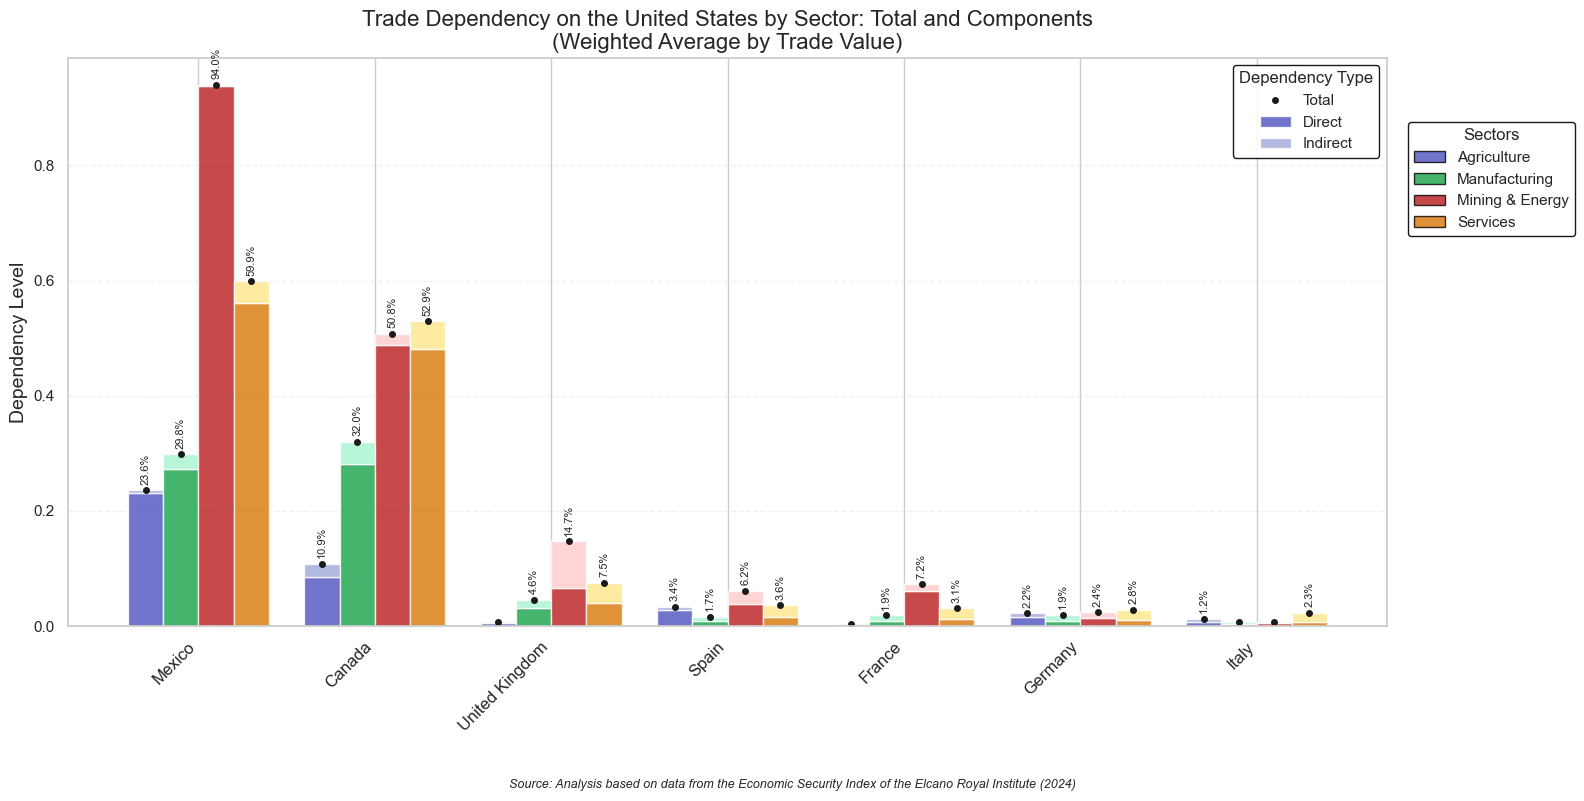

In [9]:
def plot_dependencies_ON_usa_en(csv_path, output_image_name):
    # Load data (figura6.csv uses ';')
    df = pd.read_csv(csv_path, sep=';')
    
    # Sector translation
    sector_translation = {
        'manufacturas': 'Manufacturing', 'agricultura': 'Agriculture',
        'servicios': 'Services', 'minería y energía': 'Mining & Energy'
    }
    # Country translation
    country_translation = {
        "Canadá": "Canada", "México": "Mexico", "Reino Unido": "United Kingdom",
        "España": "Spain", "Alemania": "Germany", "Francia": "France", "Italia": "Italy",
        "Canada": "Canada", "Mexico": "Mexico", "United Kingdom": "United Kingdom",
        "Spain": "Spain", "Germany": "Germany", "France": "France", "Italy": "Italy"
    }
    
    # Sorting logic similar to the provided reference code:
    # Calculate country average dependency for sorting
    country_avg_dependency = df.groupby('dependent_country')['dependency_value'].mean().reset_index()
    country_avg_dependency = country_avg_dependency.sort_values('dependency_value', ascending=False)
    ordered_countries = country_avg_dependency['dependent_country'].tolist()
    
    # Get sectors and sort them
    sectores_raw = sorted(df['sector'].unique())
    
    fig, ax = plt.subplots(figsize=(16, 8))
    group_width = 0.8
    bar_width = group_width / len(sectores_raw)
    
    # Reference colors
    colors = ['#4C51BF', '#16A34A', '#B91C1C', '#D97706']
    light_colors = ['#9FA8DA', '#A7F3D0', '#FECACA', '#FDE68A']
    
    sector_to_color = {sector: colors[i % len(colors)] for i, sector in enumerate(sectores_raw)}
    sector_to_light_color = {sector: light_colors[i % len(light_colors)] for i, sector in enumerate(sectores_raw)}
    
    for i, country in enumerate(ordered_countries):
        country_data = df[df['dependent_country'] == country]
        for j, sector in enumerate(sectores_raw):
            sector_data = country_data[country_data['sector'] == sector]
            if sector_data.empty: continue
            
            row = sector_data.iloc[0]
            direct_val = row['direct_dependency']
            indirect_val = row['indirect_dependency']
            total_val = row['dependency_value']
            
            x_pos = i + (j * bar_width) - (group_width / 2) + (bar_width / 2)
            
            ax.bar(x_pos, direct_val, bar_width, color=sector_to_color[sector], alpha=0.8, label='Direct' if i == 0 and j == 0 else "")
            ax.bar(x_pos, indirect_val, bar_width, bottom=direct_val, color=sector_to_light_color[sector], alpha=0.8, label='Indirect' if i == 0 and j == 0 else "")
            ax.plot(x_pos, total_val, 'ko', markersize=4, label='Total' if i == 0 and j == 0 else "")
            
            if total_val > 0.01:
                ax.text(x_pos, total_val + 0.01, f'{total_val:.1%}', ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_xticks(np.arange(len(ordered_countries)))
    ax.set_xticklabels([country_translation.get(c, c) for c in ordered_countries], rotation=45, ha='right', fontsize=12)
    ax.set_ylabel('Dependency Level', fontsize=14)
    ax.set_title('Trade Dependency on the United States by Sector: Total and Components\n(Weighted Average by Trade Value)', fontsize=16)
    
    handles, labels = ax.get_legend_handles_labels()
    first_legend = ax.legend(handles[:3], labels[:3], loc='upper right', title="Dependency Type", frameon=True, framealpha=0.9, edgecolor='black')
    ax.add_artist(first_legend)
    
    sector_handles = [plt.Rectangle((0, 0), 1, 1, fc=sector_to_color[s], alpha=0.8, ec='black', linewidth=1) for s in sectores_raw]
    ax.legend(sector_handles, [sector_translation.get(s, s) for s in sectores_raw], loc='upper left', bbox_to_anchor=(1.01, 0.9), title="Sectors", frameon=True, framealpha=0.9, edgecolor='black')
    
    plt.figtext(0.5, 0.005, "Source: Analysis based on data from the Economic Security Index of the Elcano Royal Institute (2024)", ha="center", fontsize=9, style='italic')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    
    plt.savefig(os.path.join("images", output_image_name), dpi=300, bbox_inches='tight')
    print(f"Figure saved as images/{output_image_name}")
    plt.show()

plot_dependencies_ON_usa_en('images/figura6.csv', 'figura6_english.png')